# Regressão Linear com PIB e Índice ABCR

## 1. Introdução

Este trabalho investiga a relação entre a atividade econômica brasileira e o fluxo de veículos nas rodovias, utilizando dados referentes ao período de 2006 a 2025.

Como indicador da atividade econômica, foi utilizado o índice de volume do Produto Interno Bruto (PIB). Para representar o fluxo de veículos nas rodovias, foi utilizado o Índice ABCR de fluxo total.

Além da análise da correlação entre os indicadores, foi desenvolvido um modelo de regressão linear simples, utilizando o índice do PIB como variável de entrada e o Índice ABCR como variável a ser estimada.

Os primeiros 16 anos da série, de 2006 a 2021, foram utilizados para treinamento do modelo, enquanto os quatro últimos anos, de 2022 a 2025, foram reservados para teste. A ordem cronológica dos dados foi preservada.

## 2. Fontes dos dados

### PIB

Os dados referentes ao índice de volume do PIB foram obtidos no Sistema IBGE de Recuperação Automática (SIDRA), por meio da Tabela 1620.

Foi considerada a série sem ajuste sazonal do PIB a preços de mercado. O índice de volume é uma série encadeada cuja média de 1995 corresponde a 100.

Fonte: IBGE — SIDRA, Tabela 1620.

https://sidra.ibge.gov.br/tabela/1620

### Índice ABCR

Para representar o fluxo de veículos foram utilizados dados do Índice ABCR, considerando o fluxo total de veículos no Brasil e a série original, sem ajuste sazonal.

Fonte: Índice ABCR.

https://melhoresrodovias.org.br/indice-abcr_2/

Célula 3 — CÓDIGO: bibliotecas

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Célula 4 — TEXTO: preparação dos dados

## 3. Preparação da base de dados

Foram selecionados 20 anos completos em comum entre as duas séries, abrangendo o período de 2006 a 2025.

Para compatibilizar as diferentes frequências dos indicadores, o `PIB_indice` representa a média dos quatro índices trimestrais do PIB de cada ano, enquanto o `ABCR_indice` representa a média dos doze índices mensais do fluxo total de veículos.

Cada linha da base corresponde, portanto, ao mesmo ano para os dois indicadores.

Célula 5 — CÓDIGO: criar a base

In [18]:
dados = {
    "Ano": [
        2006, 2007, 2008, 2009, 2010,
        2011, 2012, 2013, 2014, 2015,
        2016, 2017, 2018, 2019, 2020,
        2021, 2022, 2023, 2024, 2025
    ],

    "PIB_indice": [
        133.33, 141.46, 148.67, 148.53, 159.66,
        166.05, 169.21, 174.28, 175.15, 169.02,
        163.45, 165.57, 168.55, 170.57, 164.94,
        172.86, 178.05, 183.82, 190.06, 194.45
    ],

    "ABCR_indice": [
        107.49, 113.99, 120.91, 123.60, 133.12,
        141.44, 147.97, 153.59, 157.23, 154.25,
        148.85, 151.51, 150.44, 155.88, 135.46,
        147.11, 156.38, 165.92, 171.06, 175.34
    ]
}

df = pd.DataFrame(dados)

display(df)

,Ano,PIB_indice,ABCR_indice
0,2006,133.33,107.49
1,2007,141.46,113.99
2,2008,148.67,120.91
3,2009,148.53,123.60
4,2010,159.66,133.12
5,2011,166.05,141.44
6,2012,169.21,147.97
7,2013,174.28,153.59
8,2014,175.15,157.23
9,2015,169.02,154.25


Célula 6 — CÓDIGO: verificar a base

In [19]:
print("Primeiro ano:", df["Ano"].min())
print("Último ano:", df["Ano"].max())
print("Quantidade de anos:", len(df))

print("\nValores ausentes:")
print(df.isnull().sum())

print("\nEstatísticas descritivas:")
display(df.describe().round(2))

Primeiro ano: 2006
Último ano: 2025
Quantidade de anos: 20

Valores ausentes:
Ano            0
PIB_indice     0
ABCR_indice    0
dtype: int64

Estatísticas descritivas:


,Ano,PIB_indice,ABCR_indice
count,20.00,20.00,20.00
mean,2015.50,166.88,145.58
std,5.92,15.23,18.27
min,2006.00,133.33,107.49
25%,2010.75,162.50,134.88
50%,2015.50,168.79,149.64
75%,2020.25,174.50,156.00
max,2025.00,194.45,175.34


Célula 7 — TEXTO: análise da relação

## 4. Análise da relação entre PIB e fluxo de veículos

Inicialmente, foi construído um gráfico de dispersão para observar visualmente a relação entre o índice de volume do PIB e o Índice ABCR.

O índice do PIB é apresentado no eixo horizontal e o Índice ABCR no eixo vertical. Em seguida, foi calculado o coeficiente de correlação de Pearson entre as duas variáveis.

Célula 8 — CÓDIGO: gráfico de dispersão

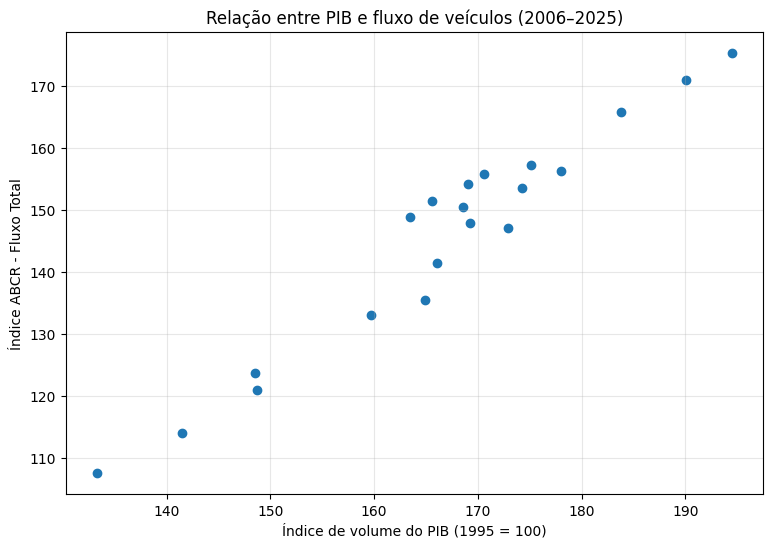

In [20]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["PIB_indice"],
    df["ABCR_indice"]
)

plt.xlabel("Índice de volume do PIB (1995 = 100)")
plt.ylabel("Índice ABCR - Fluxo Total")
plt.title("Relação entre PIB e fluxo de veículos (2006–2025)")

plt.grid(alpha=0.3)
plt.show()

Célula 9 — CÓDIGO: correlação

In [21]:
correlacao = df["PIB_indice"].corr(df["ABCR_indice"])

print(f"Correlação de Pearson: {correlacao:.4f}")

Correlação de Pearson: 0.9725


Célula 10 — TEXTO: interpretação da correlação

### Interpretação da correlação

A correlação de Pearson encontrada foi de **0,9725**, indicando uma associação linear positiva muito forte entre o índice de volume do PIB e o Índice ABCR.

Isso significa que, no período analisado, níveis mais elevados do índice do PIB estiveram geralmente associados a níveis mais elevados do fluxo de veículos.

Entretanto, uma correlação elevada não demonstra uma relação de causa e efeito. As duas variáveis podem ser influenciadas por outros fatores econômicos e sociais.

Célula 11 — TEXTO: metodologia do modelo

## 5. Treinamento do modelo de regressão linear

Foi utilizado um modelo de regressão linear simples, tendo:

- **Variável de entrada (`X`):** `PIB_indice`;
- **Variável a estimar (`y`):** `ABCR_indice`.

Os dados foram divididos cronologicamente, sem embaralhamento:

- **Treinamento:** 2006 a 2021 (16 observações);
- **Teste:** 2022 a 2025 (4 observações).

Essa divisão permite avaliar o comportamento do modelo em anos posteriores aos utilizados em seu treinamento.

Célula 12 — CÓDIGO: X, y e divisão treino/teste

In [22]:
X = df[["PIB_indice"]]
y = df["ABCR_indice"]

X_train = X.iloc[:16]
X_test = X.iloc[16:]

y_train = y.iloc[:16]
y_test = y.iloc[16:]

print("Quantidade de observações de treino:", len(X_train))
print("Quantidade de observações de teste:", len(X_test))

print("\nAnos de treinamento:")
print(df.iloc[:16]["Ano"].tolist())

print("\nAnos de teste:")
print(df.iloc[16:]["Ano"].tolist())

Quantidade de observações de treino: 16
Quantidade de observações de teste: 4

Anos de treinamento:
[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]

Anos de teste:
[2022, 2023, 2024, 2025]


Célula 13 — CÓDIGO: treinar regressão

In [23]:
modelo = LinearRegression()

modelo.fit(X_train, y_train)

intercepto = modelo.intercept_
coeficiente = modelo.coef_[0]

print(f"Intercepto: {intercepto:.4f}")
print(f"Coeficiente do PIB: {coeficiente:.4f}")

print(
    f"\nEquação estimada: "
    f"ABCR = {intercepto:.4f} + ({coeficiente:.4f} × PIB_indice)"
)

Intercepto: -58.9313
Coeficiente do PIB: 1.2294

Equação estimada: ABCR = -58.9313 + (1.2294 × PIB_indice)


Célula 14 — TEXTO: previsão

## 6. Previsões no conjunto de teste

Após o treinamento, o modelo foi utilizado para estimar o Índice ABCR dos quatro anos que não participaram do treinamento: 2022, 2023, 2024 e 2025.

A comparação entre os valores observados e previstos permite verificar o desempenho do modelo em dados posteriores ao período utilizado para seu treinamento.

Célula 15 — CÓDIGO: observado × previsto

In [24]:
y_pred = modelo.predict(X_test)

resultado = pd.DataFrame({
    "Ano": df.iloc[16:]["Ano"].values,
    "PIB_indice": X_test["PIB_indice"].values,
    "ABCR_observado": y_test.values,
    "ABCR_previsto": y_pred
})

resultado["Erro"] = (
    resultado["ABCR_observado"]
    - resultado["ABCR_previsto"]
)

display(resultado.round(2))

,Ano,PIB_indice,ABCR_observado,ABCR_previsto,Erro
0,2022,178.05,156.38,159.96,-3.58
1,2023,183.82,165.92,167.06,-1.14
2,2024,190.06,171.06,174.73,-3.67
3,2025,194.45,175.34,180.13,-4.79


Célula 16 — TEXTO

## 7. Avaliação do modelo

O desempenho da regressão foi avaliado por meio das métricas MAE, MSE e R².

- **MAE (Mean Absolute Error):** representa a média dos erros absolutos das previsões.
- **MSE (Mean Squared Error):** representa a média dos erros elevados ao quadrado, atribuindo maior peso aos erros maiores.
- **R² (coeficiente de determinação):** indica quanto da variação observada da variável dependente é explicada pelo modelo.

Célula 17 — CÓDIGO: métricas

In [25]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

metricas = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "R²"],
    "Valor": [mae, mse, r2]
})

display(metricas.round(4))

,Métrica,Valor
0,MAE,3.2934
1,MSE,12.6215
2,R²,0.7474


Célula 18 — TEXTO: interpretação das métricas

### Interpretação dos resultados

O modelo apresentou **MAE de 3,2934**, indicando que as previsões ficaram, em média, aproximadamente 3,29 pontos do Índice ABCR distantes dos valores efetivamente observados.

O **MSE foi de 12,6215**. Como essa métrica utiliza os erros elevados ao quadrado, diferenças maiores entre valores observados e previstos recebem peso maior.

O **R² foi de 0,7474**, indicando que, no conjunto de teste, o modelo explicou aproximadamente 74,74% da variação observada no Índice ABCR.

Os resultados mostram que a regressão linear simples produziu estimativas relativamente próximas dos dados reais. Entretanto, o desempenho não é perfeito, o que é esperado, pois o fluxo de veículos pode ser influenciado por diversos outros fatores além do nível de atividade econômica.

Célula 19 — CÓDIGO: reta de regressão

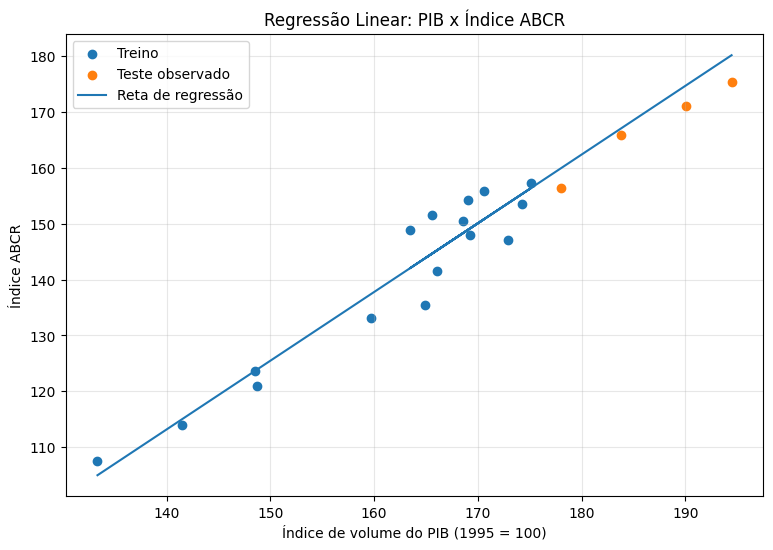

In [26]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X_train["PIB_indice"],
    y_train,
    label="Treino"
)

plt.scatter(
    X_test["PIB_indice"],
    y_test,
    label="Teste observado"
)

plt.plot(
    X["PIB_indice"],
    modelo.predict(X),
    label="Reta de regressão"
)

plt.xlabel("Índice de volume do PIB (1995 = 100)")
plt.ylabel("Índice ABCR")
plt.title("Regressão Linear: PIB x Índice ABCR")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Célula 20 — CÓDIGO: observado × previsto

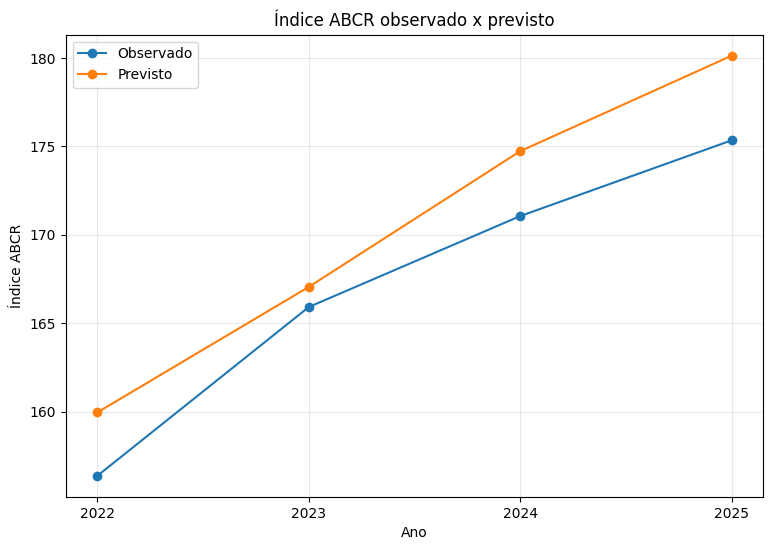

In [27]:
plt.figure(figsize=(9, 6))

plt.plot(
    resultado["Ano"],
    resultado["ABCR_observado"],
    marker="o",
    label="Observado"
)

plt.plot(
    resultado["Ano"],
    resultado["ABCR_previsto"],
    marker="o",
    label="Previsto"
)

plt.xlabel("Ano")
plt.ylabel("Índice ABCR")
plt.title("Índice ABCR observado x previsto")

plt.xticks(resultado["Ano"])
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Célula 21 — TEXTO: dificuldades

## 8. Dificuldades encontradas e soluções adotadas

Uma das principais dificuldades foi garantir a utilização das séries corretas. O Índice ABCR possui informações referentes à série original e à série dessazonalizada. Como o exercício solicita dados sem ajuste sazonal, foi necessário utilizar a série original.

Outra dificuldade foi a diferença de periodicidade entre os indicadores. O PIB possui observações trimestrais, enquanto o Índice ABCR possui dados mensais. Para permitir a comparação, foram calculadas médias anuais, utilizando os quatro trimestres do PIB e os doze meses do Índice ABCR.

Também foi necessário garantir que cada observação representasse exatamente o mesmo ano para os dois indicadores. Por esse motivo, foram selecionados 20 anos completos em comum, de 2006 a 2025.

Na etapa de modelagem, a ordem cronológica foi preservada. Os primeiros 16 anos foram utilizados para treinamento e os quatro últimos para teste, sem embaralhamento dos registros.

Célula 22 — TEXTO: conclusão

## 9. Conclusão

A análise do período de 2006 a 2025 mostrou uma forte associação positiva entre o índice de volume do PIB brasileiro e o Índice ABCR de fluxo total de veículos.

A correlação de Pearson de **0,9725** indica que níveis mais elevados de atividade econômica estiveram geralmente associados a maiores níveis de fluxo de veículos nas rodovias.

A regressão linear treinada com os dados de 2006 a 2021 apresentou capacidade de previsão razoável para 2022 a 2025. No conjunto de teste, foram obtidos **MAE de 3,2934**, **MSE de 12,6215** e **R² de 0,7474**.

Os resultados sugerem que o nível de atividade econômica contém informação relevante para explicar o comportamento do fluxo rodoviário. Entretanto, o PIB não explica sozinho todas as alterações no Índice ABCR, que também pode ser influenciado por fatores relacionados ao transporte de cargas, mobilidade, combustíveis, concessões rodoviárias e outros aspectos econômicos.

Por fim, é importante destacar que uma correlação elevada entre as variáveis **não demonstra uma relação de causa e efeito**.